In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
from tabulate import tabulate
from utils import get_p_values_from_table_data, get_kaam_hyperparameters
from data import graph_data
import matplotlib.pyplot as plt

In [2]:
dataset = 'sachs'
noise_settings = ['additive', 'nonadditive']
n = 2000  # Number of samples
N_realizations = 10
model_names = ['kan', 'kaam', 'anm', 'dbcm', 'flow']  # Models used for evaluation
metrics = ['rf_acc_obs', 'mmd_obs', 'rf_acc_int', 'mmd_int', 'mse_cf', 'mae_cf']  # Metrics used for evaluation
kaam_metrics = ['mae_uniform', 'mae_weighted']  # Additional metrics for KAAM (goodness of fit of the formula)

results_bdir = os.path.join(os.getcwd(), 'results_sachs')
data_dir = os.path.join(results_bdir, 'data')

results_table_kaam = []  # Dataset, n, node, kaam metrics, formula, formula_gt, training time
results_table_all = []  # Dataset, n, metrics and times per model
metrics_array = np.zeros((len(model_names), len(metrics), N_realizations))  # model, metric, dataset*n

names_not_kaam = ['training_time', 'model'] + [m + '_avg' for m in metrics] + ['rf_acc_int_all', 'mmd_int_all',
                                                                               'mse_cf_all',
                                                                               'mae_cf_all']  # Names of results that are not node-specific and not KAAM-specific
for noise_setting in noise_settings:
    for i_realization in range(N_realizations):
        for i_m, model_name in enumerate(model_names):
            results_file = os.path.join(data_dir, f"{dataset}_{noise_setting}_results_n_{n}_{model_name}_real_{i_realization}.pkl")
            if os.path.exists(results_file):
                with open(results_file, 'rb') as f:
                    results = pickle.load(f)
                # Prepare KAAM detailed table
                for node, r in results.items():
                    if node not in names_not_kaam and model_name == 'kaam':
                        results_table_kaam.append(
                            [dataset, node] + [str(r[m]) for m in kaam_metrics] + [str(r['formula']), str(r['formula_gt']),
                                                                                   results['training_time']])
                # Prepare all models summary table
                try:
                    results_table_all.append(
                        [dataset, model_name] + [results[m + '_avg'] for m in metrics] + [results['training_time']])
                except:
                    print('a')
                # Fill metrics array for statistical analysis
                for imetric, m in enumerate(metrics):
                    if results[m + '_avg'] is None:
                        metrics_array[i_m, imetric, i_realization] = 100  # Assign a high value if the metric is None
                    else:
                        if m=='mae_cf' and model_name in ['kan', 'kaam'] and noise_setting == 'additive':
                            metrics_array[i_m, imetric, i_realization] = results[m + '_avg'] / 2  # Divide by 2 for KAN and KAAM in additive setting
                        else:
                            metrics_array[i_m, imetric, i_realization] = results[m + '_avg']
            else:
                print(f"Results file {results_file} not found.")
    print('\n\n Average results per dataset (all models):')
    print(tabulate(results_table_all, headers=['Dataset', 'model'] + metrics + ['Time '], floatfmt=".4f",
                   tablefmt="fancy_grid"))

    # Compute a new table, where we compute average and std for each dataset
    results_table_avg = []
    for model_name in model_names:
        data_to_average = []
        for row in results_table_all:
            if row[1] == model_name:
                data_to_average.append(row[2:])
        data_to_average = np.array(data_to_average)
        mean = np.mean(data_to_average, axis=0)
        std = np.std(data_to_average, axis=0)
        string_row = [model_name] + [f'{mean[i]:.6f} ({std[i]:.6f})' for i in range(len(mean))]
        results_table_avg.append(string_row)

    print(noise_setting.upper())
    print('\n\n Average results per dataset (all models, average and std):')
    print(tabulate(results_table_avg, headers=['Model'] + metrics + ['Time '], floatfmt=".4f", tablefmt="latex"))

    #Statistical analysis
    print(f'\n\n STATISTICAL ANALYSYS FOR ALL METRICS')
    print(noise_setting.upper())
    get_p_values_from_table_data(metrics_array, alpha=0.05, higher_is_better=False, output_latex=True,
                                 list_of_methods=model_names, list_of_metrics=metrics)
    # Joint statistical analysis
    for i in range(3):
        metrics_idxs = (i * 2, i * 2 + 1)
        metric_names = [metrics[i] for i in metrics_idxs]
        print(f'\n\n STATISTICAL ANALYSYS FOR METRICS {metric_names}')
        print(noise_setting.upper())
        get_p_values_from_table_data(metrics_array[:, metrics_idxs, :], alpha=0.05, higher_is_better=False,
                                     output_latex=True, list_of_methods=model_names, list_of_metrics=metric_names)

    print('\n\n Detailed results per node (KAAM):')
    print(tabulate(results_table_kaam,
                   headers=['Dataset', 'Node'] + kaam_metrics + ['Formula', 'Formula GT', 'Training Time (s)'],
                   floatfmt=".4f", tablefmt="fancy_grid"))




 Average results per dataset (all models):
╒═══════════╤═════════╤══════════════╤═══════════╤══════════════╤═══════════╤══════════╤══════════╤══════════╕
│ Dataset   │ model   │   rf_acc_obs │   mmd_obs │   rf_acc_int │   mmd_int │   mse_cf │   mae_cf │    Time  │
╞═══════════╪═════════╪══════════════╪═══════════╪══════════════╪═══════════╪══════════╪══════════╪══════════╡
│ sachs     │ kan     │       0.5663 │    0.0009 │       0.5567 │    0.0016 │   0.0249 │   0.0301 │ 369.2172 │
├───────────┼─────────┼──────────────┼───────────┼──────────────┼───────────┼──────────┼──────────┼──────────┤
│ sachs     │ kaam    │       0.5400 │    0.0009 │       0.5672 │    0.0017 │   0.0259 │   0.0313 │ 371.8847 │
├───────────┼─────────┼──────────────┼───────────┼──────────────┼───────────┼──────────┼──────────┼──────────┤
│ sachs     │ anm     │       0.5075 │    0.0014 │       0.5263 │    0.0012 │   0.0027 │   0.0106 │   0.2599 │
├───────────┼─────────┼──────────────┼───────────┼──────────────┼──

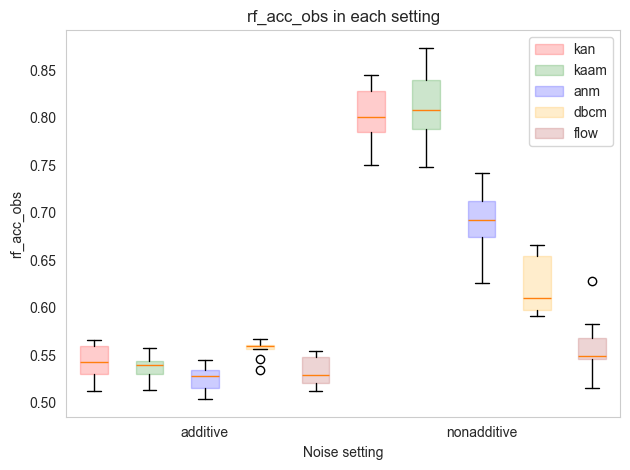

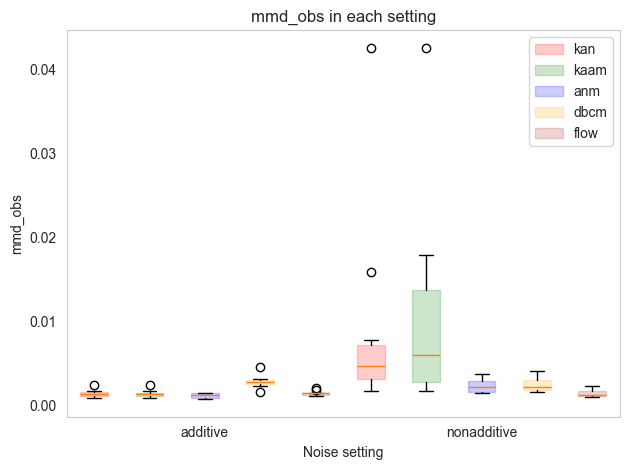

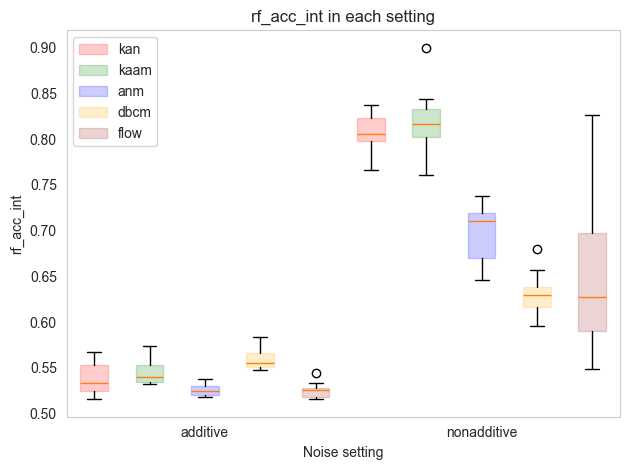

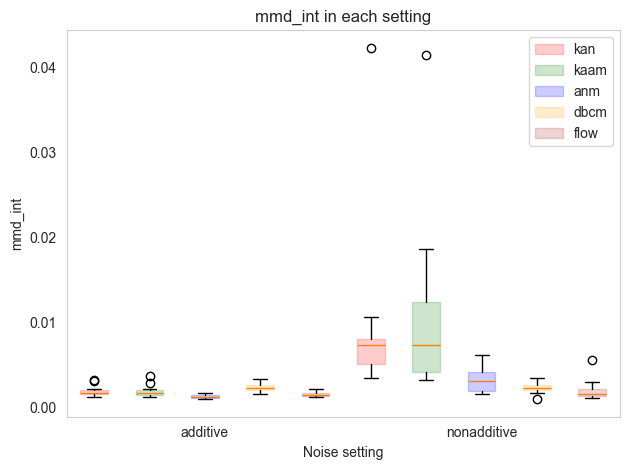

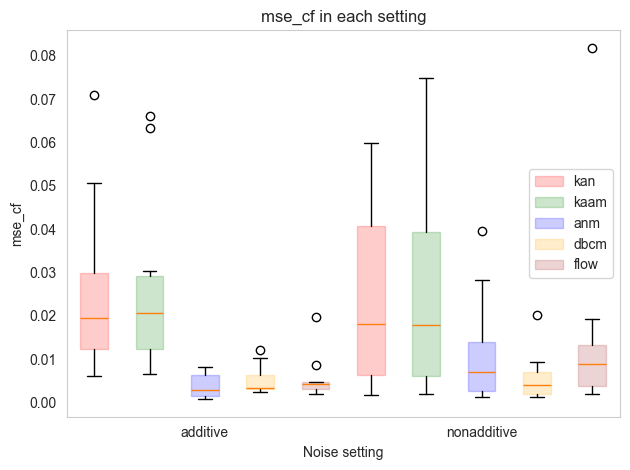

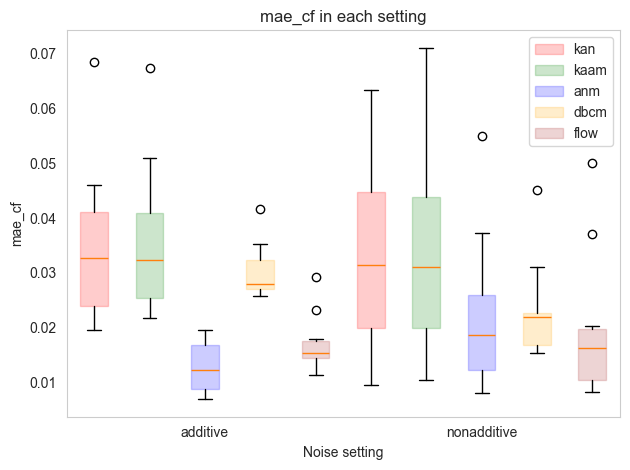

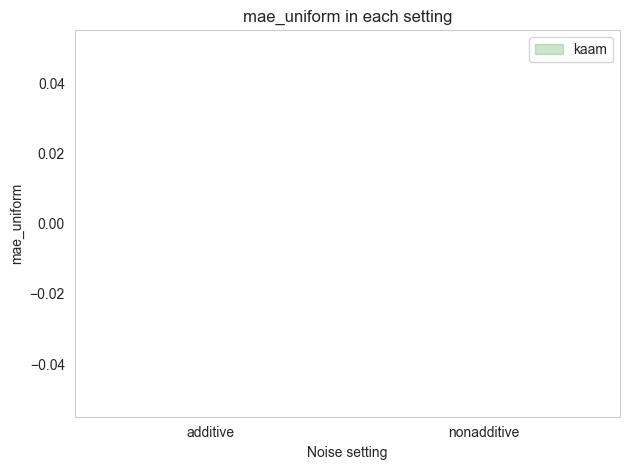

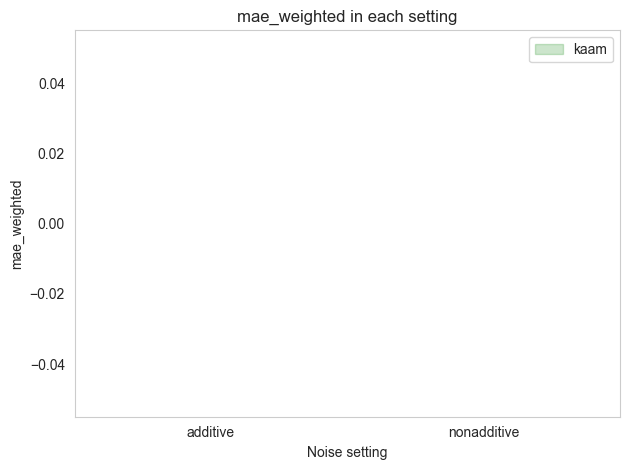

In [3]:
dataset = 'sachs'
noise_settings = ['additive', 'nonadditive']
n = 2000  # Number of samples
N_realizations = 10
model_names = ['kan', 'kaam', 'anm', 'dbcm', 'flow']  # Models used for evaluation
metrics = ['rf_acc_obs', 'mmd_obs', 'rf_acc_int', 'mmd_int', 'mse_cf', 'mae_cf']  # Metrics used for evaluation
kaam_metrics = ['mae_uniform', 'mae_weighted']  # Additional metrics for KAAM (goodness of fit of the formula)
colors = {'kan': 'r', 'kaam': 'g', 'anm': 'b', 'dbcm': 'orange', 'flow': 'brown'}
names_not_kaam = ['training_time', 'model'] + [m + '_avg' for m in metrics] + ['rf_acc_int_all', 'mmd_int_all', 'mse_cf_all', 'mae_cf_all']  # Names of results that are not node-specific and not KAAM-specific

results_bdir = os.path.join(os.getcwd(), 'results_sachs')
data_dir = os.path.join(results_bdir, 'data')

results_metrics = {}

for noise_setting in noise_settings:
    results_metrics[noise_setting] = {}
    for i_m, model_name in enumerate(model_names):
        results_metrics[noise_setting][model_name] = {}
        for metric in metrics:
            results_metrics[noise_setting][model_name][metric] = []
            if model_name == 'kaam':
                for kaam_metric in kaam_metrics:
                    results_metrics[noise_setting][model_name][kaam_metric] = []
        for i_realization in range(N_realizations):
            results_file = os.path.join(data_dir, f"{dataset}_{noise_setting}_results_n_{n}_{model_name}_real_{i_realization}.pkl")
            if os.path.exists(results_file):
                with open(results_file, 'rb') as f:
                    results = pickle.load(f)
                # Add KAAM metrics
                for kaam_metric in kaam_metrics:
                    for node, r in results.items():
                        if node not in names_not_kaam and model_name == 'kaam' and r[kaam_metric] is not None: # Note that None are source nodes, we do not include them here as they do not train a model
                            results_metrics[noise_setting][model_name][kaam_metric].append(r[kaam_metric])
                # Add the rest of metrics
                for metric in metrics:
                    results_metrics[noise_setting][model_name][metric].append(results[metric + '_avg'])
            else:
                print(f"Results file {results_file} not found.")
# Prepare for plotting
for metric in metrics + kaam_metrics:
    if metric in kaam_metrics:
        ms = ['kaam']
    else:
        ms = model_names
    positions = np.arange(len(noise_settings)) * len(ms)
    for im, model in enumerate(ms):
        plt.boxplot([results_metrics[noise_setting][model][metric] for noise_setting in noise_settings], positions=positions + im, patch_artist=True, boxprops=dict(facecolor=colors[model], color=colors[model], alpha=0.2), label=model)
    plt.xticks(positions + (len(ms) - 1)/2, noise_settings)
    plt.xlabel('Noise setting')
    plt.ylabel(metric)
    plt.legend(loc='best')
    plt.title(f'{metric} in each setting')
    # if 'mmd' in metric or 'mse' in metric or 'mae' in metric:
    #     plt.yscale('log')
    plt.grid()
    plt.tight_layout()
    plt.show()

In [4]:
import copy
results_sachs = copy.deepcopy(results_metrics)

C:\Users\Alex\AppData\Local\Temp\ipykernel_24172\81758438.py:118: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


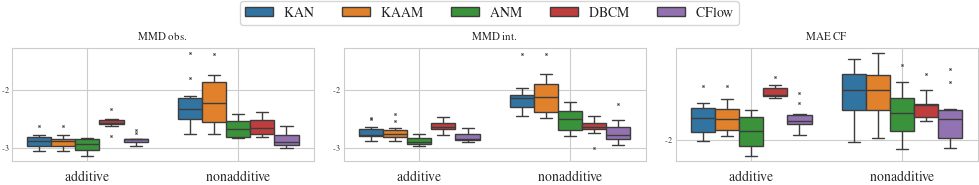

In [9]:
def nested_dict_to_df(results_dict):
    rows = []
    for noise_setting, methods in results_dict.items():          # e.g. '10', '100', ...
        for method, metrics in methods.items():      # e.g. 'anm', 'dbcm', ...
            for metric, values in metrics.items():   # e.g. 'mae_cf', 'mmd_int', ...
                for run_id, v in enumerate(values):
                    rows.append({
                        "Setting": noise_setting,
                        "Model": method,
                        "Metric": metric,
                        "run": run_id,
                        "value": v,
                    })
    return pd.DataFrame(rows)


results_df = nested_dict_to_df(results_sachs)
def exp_formatter(y, _):
    if y <= 0:
        return ""
    exp = int(np.round(np.log10(y)))
    return f"{exp}"

from tueplots import bundles
from matplotlib.ticker import FuncFormatter, LogLocator
with plt.rc_context({**bundles.icml2024(ncols=3)}):
    fig, axs = plt.subplots(1,3, figsize = (10, 1.75))
    # map the names of the metric as follows:
    metrics_map = {
    "mmd_obs": "MMD obs.",
    "rf_obs": "RF acc. obs.",
    "mmd_int": "MMD int.",
    "rf_int": "RF acc. int.",
    "ate_error": "ATE error",
    "mae_cf": "MAE CF",
    "mse_cf": "MSE CF",
    "hsic": "HSIC",
    "dhsic": "dHSIC",
    }

    model_map = {'kan': 'KAN',
                 'kaam': 'KAAM',
                 'anm': 'ANM',
                 'dbcm': 'DBCM',
                 'flow': 'CFlow',
                 }
    results_df['Metric'] = results_df['Metric'].map(metrics_map)
    results_df['Model'] =  results_df['Model'].map(model_map)




    metrics_to_plot = ['MMD obs.', 'MMD int.', 'MAE CF']

    # in df, when metric == CF MAE, model is KAN or KAAM, and Setting is 'additive', reduce to the half the value
    # python
    mask = (
        (results_df['Metric'] == 'MAE CF') &
        (results_df['Model'].isin(['KAN', 'KAAM'])) &
        (results_df['Setting'] == 'additive')
    )

    # índices que cumplen la condición
    idx = results_df[mask].index

    # convertir a numérico (errores -> NaN)
    numeric = pd.to_numeric(results_df.loc[idx, 'value'], errors='coerce')

    # máscara de valores numéricos válidos
    valid = numeric.notna()

    # dividir por 2 solo los valores numéricos válidos
    results_df.loc[idx[valid], 'value'] = numeric[valid] / 2.0

    flierprops = dict(
    marker='x',
    markersize=1.5,      # smaller size
    markeredgewidth=0.7
)
    for ii, metric in enumerate(metrics_to_plot):
        sns.boxplot(data=results_df[results_df['Metric'] == metric],
                    x='Setting', y='value', hue='Model',
                    ax=axs[ii],
                    flierprops=flierprops
                    )
        axs[ii].set_yscale("log")
    axs[0].legend()
    handles, labels = axs[0].get_legend_handles_labels()
    # remove legends
    for ax in axs:
        ax.legend().remove()
        ax.tick_params(axis='y', which='major', pad=-1)
        ax.tick_params(axis='x', labelsize=10)
        ax.yaxis.set_major_locator(LogLocator(base=10))
        ax.yaxis.set_major_formatter(FuncFormatter(exp_formatter))
        ax.set_xlabel('')



    axs[1].sharey(axs[0])
    # axs[1].set_yticklabels([])

    for ax, metric in zip(axs.flat, metrics_to_plot):
        ax.set_ylabel('')
        ax.set_title(metric)
        ax.grid(True)

    # single legend above the plots with frame
    fig.legend(
        handles, labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.15),
        ncol=5,
        frameon=True,
        fontsize=  10
    )

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.1)
    plt.savefig("sachs_results.pdf", dpi=300, bbox_inches="tight")
    plt.show()